In [1]:
#%pip install ipywidgets
#%pip install metrics

In [2]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torchsummary import summary

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


s:\intenship\project1\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- Data paths ---
DATA_DIR = r'S:\intenship\project1\data'
x_train_dir = os.path.join(DATA_DIR, 'train', 'images')
y_train_dir = os.path.join(DATA_DIR, 'train', 'masks')
x_valid_dir = os.path.join(DATA_DIR, 'val', 'images')
y_valid_dir = os.path.join(DATA_DIR, 'val', 'masks')
x_test_dir  = os.path.join(DATA_DIR, 'test', 'images')
select_class_gray_values = [255]


In [4]:
def visualize(**images):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.title(name)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()

In [5]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from glob import glob
import os

def fill_mask_border(mask):
    """Fill the white ellipse border in a binary mask to create a solid region."""
    mask = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(mask)
    cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)
    return (filled_mask / 255).astype(np.float32)

class FetalHeadDataset(Dataset):
    def __init__(self, images_dir, masks_dir, class_gray_values, augmentation=None, preprocessing=None):
        self.image_paths = sorted(glob(os.path.join(images_dir, '*')))
        self.mask_paths  = sorted(glob(os.path.join(masks_dir, '*')))
        self.class_gray_values = class_gray_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, i):
        image = cv2.imread(self.image_paths[i], cv2.IMREAD_GRAYSCALE)
        mask  = cv2.imread(self.mask_paths[i],  cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {self.image_paths[i]}")
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {self.mask_paths[i]}")

        # Normalize image
        image = image.astype('float32') / 255.0

        # Fill ellipse in mask
        mask = fill_mask_border(mask)

        # Optional: filter to specific classes if needed
        if self.class_gray_values:
            mask = np.isin(mask * 255, self.class_gray_values).astype('float32')  # Recheck gray value logic
        else:
            mask = mask.astype('float32')

        image = np.expand_dims(image, -1)
        mask  = np.expand_dims(mask, -1)

        if self.augmentation:
            augmented = self.augmentation(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        if self.preprocessing:
            processed = self.preprocessing(image=image, mask=mask)
            image, mask = processed['image'], processed['mask']

        if isinstance(mask, torch.Tensor):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = mask.squeeze(-1)
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = mask.permute(2, 0, 1)
        elif isinstance(mask, np.ndarray):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = np.squeeze(mask, axis=-1)
            if mask.ndim == 2:
                mask = np.expand_dims(mask, 0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = np.transpose(mask, (2, 0, 1))
            mask = torch.from_numpy(mask).float()

        assert mask.shape == (1, 256, 256), f"Mask shape: {mask.shape}"

        if isinstance(image, torch.Tensor):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = image.squeeze(-1)
            if image.ndim == 2:
                image = image.unsqueeze(0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = image.permute(2, 0, 1)
        elif isinstance(image, np.ndarray):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = np.squeeze(image, axis=-1)
            if image.ndim == 2:
                image = np.expand_dims(image, 0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = np.transpose(image, (2, 0, 1))
            image = torch.from_numpy(image).float()

        assert image.shape == (1, 256, 256), f"Image shape: {image.shape}"

        return image, mask


# Augumentation


In [6]:
def get_training_augmentation():
    return A.Compose([
        A.PadIfNeeded(256, 256),
        A.RandomCrop(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.15),
        A.GaussNoise(var_limit=(10.0,50.0), p=0.1),
    ])

def get_validation_augmentation():
    return A.Compose([
        A.PadIfNeeded(256,256),
        A.CenterCrop(256,256)
    ])

def get_preprocessing():
    return A.Compose([
        A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=1.0),
        ToTensorV2()
    ])

In [7]:
BATCH_SIZE = 8
NUM_WORKERS = 0

train_dataset = FetalHeadDataset(
    x_train_dir, y_train_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing()
)
val_dataset = FetalHeadDataset(
    x_valid_dir, y_valid_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing()
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)


In [8]:
%pip install torchinfo


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import segmentation_models_pytorch as smp
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="vgg16",          # Use VGG16 instead of ResNet
    encoder_weights="imagenet",    # Use pretrained ImageNet weights
    in_channels=1,                 # Grayscale input
    classes=1,                     # Binary segmentation
    activation=None
).to(DEVICE)

from torchinfo import summary
summary(model, input_size=(BATCH_SIZE, 1, 256, 256))



Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [8, 1, 256, 256]          --
├─VGGEncoder: 1-1                             [8, 64, 256, 256]         --
│    └─Sequential: 2-1                        --                        --
│    │    └─Conv2d: 3-1                       [8, 64, 256, 256]         640
│    │    └─ReLU: 3-2                         [8, 64, 256, 256]         --
│    │    └─Conv2d: 3-3                       [8, 64, 256, 256]         36,928
│    │    └─ReLU: 3-4                         [8, 64, 256, 256]         --
│    │    └─MaxPool2d: 3-5                    [8, 64, 128, 128]         --
│    │    └─Conv2d: 3-6                       [8, 128, 128, 128]        73,856
│    │    └─ReLU: 3-7                         [8, 128, 128, 128]        --
│    │    └─Conv2d: 3-8                       [8, 128, 128, 128]        147,584
│    │    └─ReLU: 3-9                         [8, 128, 128, 128]        --
│    │

In [10]:
'''model = UNet(in_channels=1, out_channels=1).to(DEVICE)
print('Number of parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))'''


"model = UNet(in_channels=1, out_channels=1).to(DEVICE)\nprint('Number of parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))"

In [11]:
from segmentation_models_pytorch.losses import FocalLoss
import segmentation_models_pytorch as smp
import torch
import numpy as np
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)  # Needed because you use logits
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        smooth = 1.
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice + self.bce(inputs, targets)


# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5, min_lr=1e-6)

# Helper metric functions
def safe_div(numerator, denominator):
    return (numerator + 1e-7) / (denominator + 1e-7) if denominator != 0 else 0.0


In [12]:
def iou_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    union = (outputs + labels).clamp(0, 1).sum()
    return safe_div(intersection, union)

def dice_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    total = outputs.sum() + labels.sum()
    return safe_div(2 * intersection, total)

def precision_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fp = (outputs * (1 - labels)).sum()
    return safe_div(tp, tp + fp)

def recall_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fn = ((1 - outputs) * labels).sum()
    return safe_div(tp, tp + fn)

def accuracy_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    correct = (outputs == labels).float().sum()
    total = torch.numel(outputs)
    return safe_div(correct, total)

def f1_score_pytorch(outputs, labels, threshold=0.5):
    prec = precision_pytorch(outputs, labels, threshold)
    rec = recall_pytorch(outputs, labels, threshold)
    return safe_div(2 * prec * rec, prec + rec)

In [13]:
def train_epoch(loader, model, loss_fn, optimizer, device):
    model.train()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    for images, masks in tqdm(loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss_fn = DiceBCELoss()
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)

        metrics['loss'] += loss.item()
        metrics['iou'] += iou_pytorch(probs, masks)
        metrics['dice'] += dice_pytorch(probs, masks)
        metrics['precision'] += precision_pytorch(probs, masks)
        metrics['recall'] += recall_pytorch(probs, masks)
        metrics['accuracy'] += accuracy_pytorch(probs, masks)
        metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

def eval_epoch(loader, model, loss_fn, device):
    model.eval()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss_fn = DiceBCELoss()
            loss = loss_fn(logits, masks)
            probs = torch.sigmoid(logits)

            metrics['loss'] += loss.item()
            metrics['iou'] += iou_pytorch(probs, masks)
            metrics['dice'] += dice_pytorch(probs, masks)
            metrics['precision'] += precision_pytorch(probs, masks)
            metrics['recall'] += recall_pytorch(probs, masks)
            metrics['accuracy'] += accuracy_pytorch(probs, masks)
            metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

In [14]:
NUM_EPOCHS = 100
PATIENCE = 25  # stop if no improvement after 25 epochs
counter = 0

best_val_iou, best_epoch = 0, 0
best_model_path = os.path.join(DATA_DIR, 'best_model_unet.pth')

log = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': [],
    'train_dice': [], 'val_dice': [],
    'train_precision': [], 'val_precision': [],
    'train_accuracy': [], 'val_accuracy': [],
    'train_recall': [], 'val_recall': [],
    'train_f1': [], 'val_f1': []
}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # Training
    train_metrics = train_epoch(train_loader, model, DiceBCELoss, optimizer, DEVICE)

    # Validation
    val_metrics = eval_epoch(val_loader, model, DiceBCELoss, DEVICE)

    # Scheduler step
    lr_scheduler.step(val_metrics['loss'])

    # Logging
    print(f"Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"Train IoU: {train_metrics['iou']:.4f} | Val IoU: {val_metrics['iou']:.4f}")
    print(f"Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"Train Precision: {train_metrics['precision']:.4f} | Val Precision: {val_metrics['precision']:.4f}")
    print(f"Train Accuracy: {train_metrics['accuracy']:.4f} | Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Train Recall: {train_metrics['recall']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
    print(f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")

    for key in log.keys():
        metric_name = key.split('_', 1)[1]
        if key.startswith('train_'):
            log[key].append(train_metrics[metric_name])
        else:
            log[key].append(val_metrics[metric_name])

    # Early Stopping & Save Best Model
    if val_metrics['iou'] > best_val_iou:
        best_val_iou, best_epoch = val_metrics['iou'], epoch
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best checkpoint saved at epoch {epoch+1} with Val IoU: {best_val_iou:.4f}")
        counter = 0  # reset counter if improved
    else:
        counter += 1
        print(f"⏳ No improvement for {counter} epoch(s).")

    if counter >= PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        break

# Final summary
print(f"\n🏁 Best Val IoU: {best_val_iou:.4f} at epoch {best_epoch+1}")



Epoch 1/100


100%|██████████| 101/101 [00:55<00:00,  1.81it/s]


Train Loss: 0.9330 | Val Loss: 0.4661
Train IoU: 0.6639 | Val IoU: 0.8932
Train Dice: 0.7920 | Val Dice: 0.9307
Train Precision: 0.7137 | Val Precision: 0.9584
Train Accuracy: 0.7356 | Val Accuracy: 0.8987
Train Recall: 0.9075 | Val Recall: 0.9303
Train F1: 0.7920 | Val F1: 0.9307
✅ Best checkpoint saved at epoch 1 with Val IoU: 0.8932

Epoch 2/100


100%|██████████| 101/101 [00:41<00:00,  2.45it/s]


Train Loss: 0.8296 | Val Loss: 0.4020
Train IoU: 0.7303 | Val IoU: 0.9564
Train Dice: 0.8394 | Val Dice: 0.9739
Train Precision: 0.7880 | Val Precision: 0.9631
Train Accuracy: 0.8180 | Val Accuracy: 0.9598
Train Recall: 0.9161 | Val Recall: 0.9930
Train F1: 0.8394 | Val F1: 0.9739
✅ Best checkpoint saved at epoch 2 with Val IoU: 0.9564

Epoch 3/100


...

Train Loss: 0.5364 | Val Loss: 0.3714
Train IoU: 0.9300 | Val IoU: 0.9670
Train Dice: 0.9628 | Val Dice: 0.9793
Train Precision: 0.9645 | Val Precision: 0.9899
Train Accuracy: 0.9595 | Val Accuracy: 0.9688
Train Recall: 0.9634 | Val Recall: 0.9770
Train F1: 0.9628 | Val F1: 0.9793
⏳ No improvement for 23 epoch(s).

Epoch 51/100


100%|██████████| 101/101 [00:40<00:00,  2.49it/s]


Train Loss: 0.5451 | Val Loss: 0.3712
Train IoU: 0.9235 | Val IoU: 0.9675
Train Dice: 0.9596 | Val Dice: 0.9794
Train Precision: 0.9621 | Val Precision: 0.9893
Train Accuracy: 0.9563 | Val Accuracy: 0.9693
Train Recall: 0.9584 | Val Recall: 0.9782
Train F1: 0.9596 | Val F1: 0.9794
⏳ No improvement for 24 epoch(s).

Epoch 52/100


100%|██████████| 101/101 [00:40<00:00,  2.50it/s]


Train Loss: 0.5320 | Val Loss: 0.3832
Train IoU: 0.9321 | Val IoU: 0.9567
Train Dice: 0.9642 | Val Dice: 0.9709
Train Precision: 0.9660 | Val Precision: 0.9905
Train Accuracy: 0.9601 | Val Accuracy: 0.9586
Train Recall: 0.9643 | Val Recall: 0.9662
Train F1: 0.9642 | Val F1: 0.9709
⏳ No improvement for 25 epoch(s).

🛑 Early stopping triggered at epoch 52

🏁 Best Val IoU: 0.9831 at epoch 27


In [15]:
import matplotlib.pyplot as plt
import torch

def to_numpy(x):
    """Convert tensor to numpy, handling GPU tensors."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x

def plot_training_history(log):
    metrics = [
        ("loss", "Loss"),
        ("iou", "IoU"),
        ("dice", "Dice"),
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("accuracy", "Accuracy"),
        ("f1", "F1 Score")
    ]

    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 3))

    if len(metrics) == 1:
        axes = [axes]

    for ax, (key, title) in zip(axes, metrics):
        train_key = f"train_{key}"
        val_key = f"val_{key}"

        if train_key in log and val_key in log:
            train_vals = [to_numpy(v) for v in log[train_key]]
            val_vals = [to_numpy(v) for v in log[val_key]]

            ax.plot(train_vals, label=f"Train {title}", marker='o')
            ax.plot(val_vals, label=f"Val {title}", marker='o')
            ax.set_title(f"{title} over Epochs")
            ax.set_xlabel("Epoch")
            ax.set_ylabel(title)
            ax.grid(True)
            ax.legend()

    plt.tight_layout()
    plt.show()


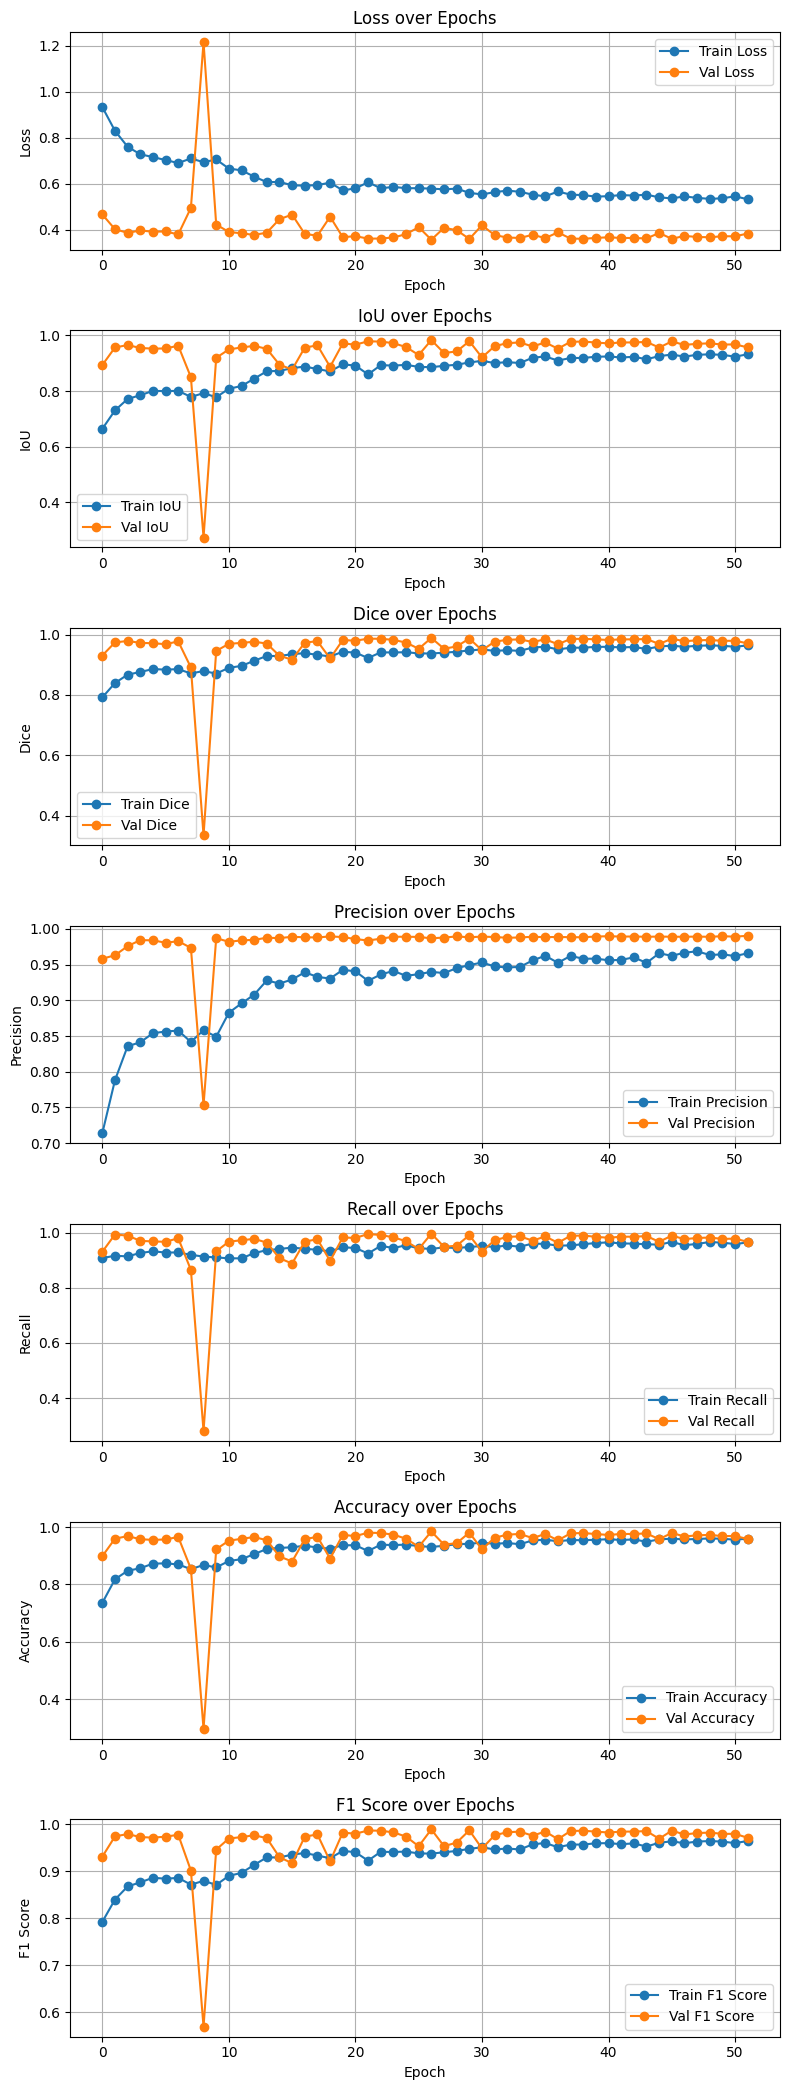

In [16]:
plot_training_history(log)


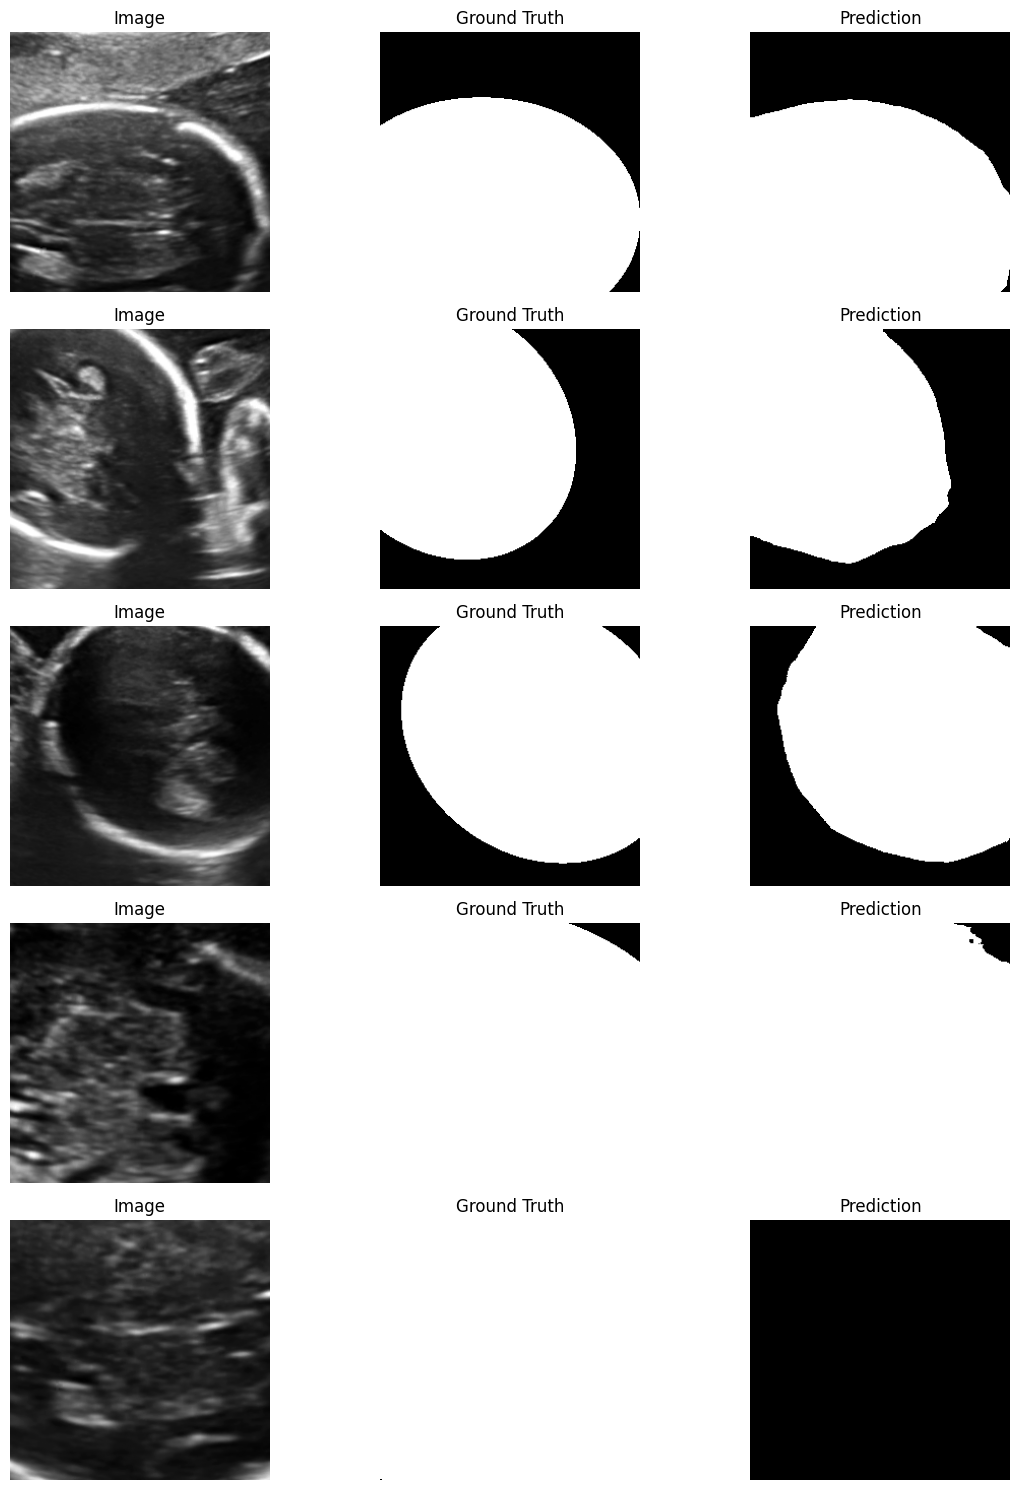

In [17]:
import matplotlib.pyplot as plt

# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# Show predictions on a few validation samples
n_samples = 5  # Number of images to visualize
fig, axs = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))

with torch.no_grad():
    for i in range(n_samples):
        # Get image and mask from validation dataset
        img, mask = val_dataset[i]
        img_input = img.unsqueeze(0).to(DEVICE)

        # Predict
        pred = torch.sigmoid(model(img_input))
        pred_mask = (pred[0, 0].cpu().numpy() > 0.5)

        # Plot
        axs[i, 0].imshow(img[0].cpu(), cmap='gray')
        axs[i, 0].set_title("Image")
        axs[i, 0].axis('off')

        axs[i, 1].imshow(mask[0].cpu(), cmap='gray')
        axs[i, 1].set_title("Ground Truth")
        axs[i, 1].axis('off')

        axs[i, 2].imshow(pred_mask, cmap='gray')
        axs[i, 2].set_title("Prediction")
        axs[i, 2].axis('off')

plt.tight_layout()
plt.show()


# testing

In [18]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torchinfo import summary
from typing import Optional, Tuple

# ---------------------------
# Configuration
# ---------------------------
DATA_DIR = r"S:\intenship\project1\data"
IMAGE_DIR = os.path.join(DATA_DIR, "test", "images")
SAVE_DIR = os.path.join(DATA_DIR, "test", "predicted_masks_unet")

MODEL_PATH = r"S:\intenship\project1\data\best_model_unet.pth"   # FIXED

GT_DIR = os.path.join(DATA_DIR, "test", "masks")

BATCH_SIZE = 1
IMG_SIZE = 256
PIXEL_TO_MM = 0.13
MASK_AREA_THRESH = 100
PRED_THRESH = 0.6  
GAMMA = 0.7
CLIP_PERCENTILE = 99.5
COLORMAP = cv2.COLORMAP_TURBO

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(SAVE_DIR, exist_ok=True)
print("Using device:", DEVICE)

# ---------------------------
# Dataset
# ---------------------------
class TestDataset(Dataset):
    def __init__(self, image_paths, img_size=IMG_SIZE):
        self.image_paths = image_paths
        self.transform = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        augmented = self.transform(image=img)
        return augmented['image'], path

# ---------------------------
# Mask Cleaning
# ---------------------------
def postprocess_binary_mask(mask, area_thresh=MASK_AREA_THRESH):
    mask_u8 = (mask.astype(np.uint8) * 255)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_closed = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel, iterations=2)
    _, mask_bin = cv2.threshold(mask_closed, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cleaned = np.zeros_like(mask_bin)
    for c in contours:
        if cv2.contourArea(c) > area_thresh:
            cv2.drawContours(cleaned, [c], -1, 255, cv2.FILLED)

    return (cleaned // 255).astype(np.uint8)

# ---------------------------
# HC Calculation
# ---------------------------
def calculate_head_circumference(mask_np, pixel_to_mm=PIXEL_TO_MM):
    mask_u8 = (mask_np.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0, None

    largest = max(contours, key=cv2.contourArea)
    perimeter_px = cv2.arcLength(largest, True)
    return float(perimeter_px * pixel_to_mm), largest

# ---------------------------
# Grad-CAM Utilities
# ---------------------------
def find_best_gradcam_layer(model):
    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    return convs[-1]  # UNet-VGG16 last conv layer

def normalize_cam(cam, clip_percentile=CLIP_PERCENTILE, gamma=GAMMA):
    top = np.percentile(cam, clip_percentile)
    cam = np.clip(cam, None, top)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    cam = cam ** gamma
    return cam

def apply_gradcam(model, input_tensor, target_layer, out_size=IMG_SIZE):
    activations = []
    gradients = []

    def forward_hook(m, i, o):
        activations.append(o.detach())

    def backward_hook(m, gi, go):
        gradients.append(go[0].detach())

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    x = input_tensor.clone().detach().requires_grad_(True)
    out = model(x)
    out.mean().backward()

    act = activations[0]
    grad = gradients[0]

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * act).sum(dim=1))[0].cpu().numpy()

    fh.remove()
    bh.remove()

    cam = cv2.resize(cam, (out_size, out_size))
    return normalize_cam(cam)

# ---------------------------
# IoU / Dice
# ---------------------------
def compute_iou_and_dice(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    inter = (pred & gt).sum()
    union = (pred | gt).sum()
    iou = inter / union if union else 0
    dice = 2 * inter / (pred.sum() + gt.sum() + 1e-8)
    return float(iou), float(dice)

# ---------------------------
# Build UNet (VGG16)
# ---------------------------
model = smp.Unet(
    encoder_name="vgg16",         # FIXED
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
).to(DEVICE)

print(summary(model, input_size=(1, 1, 256, 256)))

# Load weights
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

# Grad-CAM layer
target_layer = find_best_gradcam_layer(model)

# ---------------------------
# Load Data
# ---------------------------
test_image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))
test_loader = DataLoader(TestDataset(test_image_paths), batch_size=1, shuffle=False)

# ---------------------------
# Output Folders
# ---------------------------
folders = {
    "original": os.path.join(SAVE_DIR, "original"),
    "predicted_mask": os.path.join(SAVE_DIR, "predicted_mask"),
    "overlay": os.path.join(SAVE_DIR, "overlay"),
    "gradcam": os.path.join(SAVE_DIR, "gradcam"),
    "hc_contour": os.path.join(SAVE_DIR, "hc_contour")
}
for f in folders.values():
    os.makedirs(f, exist_ok=True)

# ---------------------------
# Inference
# ---------------------------
results = []
eval_metrics = []
gradcam_align = []

for idx, (images, paths) in enumerate(test_loader):
    images = images.to(DEVICE)
    path = paths[0]
    name = os.path.splitext(os.path.basename(path))[0]
    print(f"[{idx+1}/{len(test_image_paths)}] {name}")

    # Prediction
    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()[0, 0]
        pred_mask = (probs > PRED_THRESH).astype(np.uint8)

    pred_mask_clean = postprocess_binary_mask(pred_mask)
    hc_mm, contour = calculate_head_circumference(pred_mask_clean)

    # Load image
    orig = cv2.imread(path, 0)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    orig_c = cv2.cvtColor(orig, cv2.COLOR_GRAY2BGR)

    # Save original
    cv2.imwrite(os.path.join(folders["original"], f"{name}_original.png"), orig_c)

    # Save predicted mask
    mask_color = cv2.cvtColor(pred_mask_clean * 255, cv2.COLOR_GRAY2BGR)
    cv2.imwrite(os.path.join(folders["predicted_mask"], f"{name}_mask.png"), mask_color)

    # HC contour
    contour_img = orig_c.copy()
    if contour is not None:
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 2)
    cv2.imwrite(os.path.join(folders["hc_contour"], f"{name}_hc.png"), contour_img)

    # Grad-CAM
    try:
        cam = apply_gradcam(model, images, target_layer)
    except:
        cam = np.zeros((IMG_SIZE, IMG_SIZE))

    cam_color = cv2.applyColorMap((cam * 255).astype(np.uint8), COLORMAP)
    cv2.imwrite(os.path.join(folders["gradcam"], f"{name}_gradcam.png"), cam_color)

    # Overlay CAM + image
    overlay = np.uint8(np.clip(0.6*(orig_c/255) + 0.4*(cam_color/255), 0, 1) * 255)
    cv2.imwrite(os.path.join(folders["overlay"], f"{name}_overlay.png"), overlay)

    # Save metrics
    results.append({"Image": name, "HC (mm)": round(hc_mm,2)})

    # GT evaluation
    gt_path = os.path.join(GT_DIR, os.path.basename(path))
    if os.path.exists(gt_path):
        gt = cv2.imread(gt_path, 0)
        gt = cv2.resize(gt, (IMG_SIZE, IMG_SIZE))
        gt_bin = (gt > 127).astype(np.uint8)
        iou, dice = compute_iou_and_dice(pred_mask_clean, gt_bin)
        eval_metrics.append({"Image": name, "IoU": iou, "Dice": dice})

# ---------------------------
# Save CSV
# ---------------------------
pd.DataFrame(results).to_csv(os.path.join(SAVE_DIR,"head_circumference_results.csv"), index=False)
pd.DataFrame(eval_metrics).to_csv(os.path.join(SAVE_DIR,"segmentation_eval_metrics.csv"), index=False)

print("✓ DONE")


Using device: cuda
Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [1, 1, 256, 256]          --
├─VGGEncoder: 1-1                             [1, 64, 256, 256]         --
│    └─Sequential: 2-1                        --                        --
│    │    └─Conv2d: 3-1                       [1, 64, 256, 256]         640
│    │    └─ReLU: 3-2                         [1, 64, 256, 256]         --
│    │    └─Conv2d: 3-3                       [1, 64, 256, 256]         36,928
│    │    └─ReLU: 3-4                         [1, 64, 256, 256]         --
│    │    └─MaxPool2d: 3-5                    [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-6                       [1, 128, 128, 128]        73,856
│    │    └─ReLU: 3-7                         [1, 128, 128, 128]        --
│    │    └─Conv2d: 3-8                       [1, 128, 128, 128]        147,584
│    │    └─ReLU: 3-9                         [1, 128, 128, 12